In [24]:
!pip install statsmodels


[notice] A new release of pip is available: 23.1.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import ttest_ind, chi2_contingency

# Load the merged dataset
df = pd.read_csv('../../data/merged/merged_final.csv', low_memory=False)


####        Hypothesis 1: Sustainability Score
H0: There is no difference in sustainability_score between churned and non-churned customers  
H1: There is a significant difference in sustainability_score between churned and non-churned customers  
Test Type: T-Test

In [53]:
churn = df[df["churn"] == 1]['sustainability_score']
non_churn = df[df["churn"] == 0]['sustainability_score']

t, p = ttest_ind(churn, non_churn, nan_policy='omit')
print("p-value:", p)
if p < 0.05:
    print("Reject H0 hypothesis: There is a significant difference in sustainability scores between churned and non-churned customers.")
else:    
    print("Fail to reject H0 hypothesis: There is no significant difference in sustainability scores between churned and non-churned customers.")

p-value: 0.0
Reject H0 hypothesis: There is a significant difference in sustainability scores between churned and non-churned customers.


####        Hypothesis 2: Total amount paid by customer

H0: Payment amount does not affect churn  
H1: Lower paying customers churn more  
Test Type: T-test

In [54]:
t, p = ttest_ind(
    df[df["churn"]==1]['total_net_paid'],
    df[df["churn"]==0]['total_net_paid'],
    nan_policy='omit'
)
print(p)
if p < 0.05:
    print("Reject H0 hypothesis: There is a significant difference in total net paid between churned and non-churned customers.")
else:    
    print("Fail to reject H0 hypothesis: There is no significant difference in total net paid between churned and non-churned customers.")

2.2356982182755685e-55
Reject H0 hypothesis: There is a significant difference in total net paid between churned and non-churned customers.


####        Hypothesis 3

H0: Number of calls has no effect  
H1: Higher number of calls increases churn  
Test Type: T-test

In [13]:
t, p = ttest_ind(
    df[df["churn"]==1]['num_cc_calls'],
    df[df["churn"]==0]['num_cc_calls'],
    nan_policy='omit'
)
print(p)
if p < 0.05:
    print("Reject H0 hypothesis: There is a significant difference in number of customer care calls between churned and non-churned customers.")
else:    
    print("Fail to reject H0 hypothesis: There is no significant difference in number of customer care calls between churned and non-churned customers.")

6.9290293884649385e-87
Reject H0 hypothesis: There is a significant difference in number of customer care calls between churned and non-churned customers.


####    Hypothesis 4: cc_pricing_sentiment_impact
H0: Pricing sentiment has no effect  
H1: Negative pricing sentiment increases churn  
Test Type: Chi-square

In [74]:
table = pd.crosstab(df['cc_pricing_sentiment_impact'], df["churn"])
chi2, p, _, _ = chi2_contingency(table)
print(p)
if p < 0.05:
    print("Reject H0 hypothesis: There is a significant association between customer care pricing sentiment impact and churn.")
else:    
    print("Fail to reject H0 hypothesis: There is no significant association between customer care pricing sentiment impact and churn.")


0.666146743474241
Fail to reject H0 hypothesis: There is no significant association between customer care pricing sentiment impact and churn.


####        Hypothesis 5 : payment_timeframe
H0: Payment timeframe does not affect churn  
H1: Customers with delayed payments are more likely to churn  
Test Type: T-test

In [72]:
t, p = ttest_ind(
    df[df['churn']==1]['payment_timeframe'],
    df[df['churn']==0]['payment_timeframe'],
    nan_policy='omit'
)
print(p)
if p < 0.05:
    print("Reject H0 hypothesis: There is a significant difference in payment timeframe between churned and non-churned customers.")        
else:
    print("Fail to reject H0 hypothesis: There is no significant difference in payment timeframe between churned and non-churned customers.")


2.07421951859337e-30
Reject H0 hypothesis: There is a significant difference in payment timeframe between churned and non-churned customers.


####        Hypothesis 6 : price_switching_flag
H0: Price switching has no impact on churn  
H1: Customers sensitive to price are more likely to churn  
Test Type: Chi-square

In [ ]:
table = pd.crosstab(df['price_switching_flag'], df['churn'])
chi2, p, _, _ = chi2_contingency(table)
print(p)
if p < 0.05:
    print("Reject H0 hypothesis: There is a significant association between price switching and churn.")   
else:    
    print("Fail to reject H0 hypothesis: There is no significant association between price switching and churn.")

9.110311295206637e-09
Reject H0 hypothesis: There is a significant association between price switching and churn.


####        Hypothesis : discount_requested_flag
H0: Requesting discount does not affect churn  
H1: Customers asking for discount are more likely to churn  
Test Type: Chi-square

In [62]:
table = pd.crosstab(df['discount_requested_flag'], df['churn'])
chi2, p, _, _ = chi2_contingency(table)
print(p)
if p < 0.05:
    print("Reject H0 hypothesis: There is a significant association between discount requested and churn.")
else:    
    print("Fail to reject H0 hypothesis: There is no significant association between discount requested and churn.")


1.0
Fail to reject H0 hypothesis: There is no significant association between discount requested and churn.


####        Hypothesis : competitor_mentioned_flag
H0: Competitor mention has no impact  
H1: Customers mentioning competitors are more likely to churn  
Test Type: Chi-square

In [44]:
table = pd.crosstab(df['competitor_mentioned_flag'], df['churn'])
chi2, p, _, _ = chi2_contingency(table)
print(p)
if p < 0.05:
    print("Reject H0 hypothesis: There is a significant association between competitor mentioned and churn.")
else:    
    print("Fail to reject H0 hypothesis: There is no significant association between competitor mentioned and churn.")

1.4109489836608423e-07
Reject H0 hypothesis: There is a significant association between competitor mentioned and churn.


####        Hypothesis : hardship_flag
H0: Financial hardship has no impact  
H1: Financial hardship increases churn  
Test Type: Chi-square

1.2400340184283941e-286
Reject H0 hypothesis: There is a significant association between financial hardship mentioned and churn.


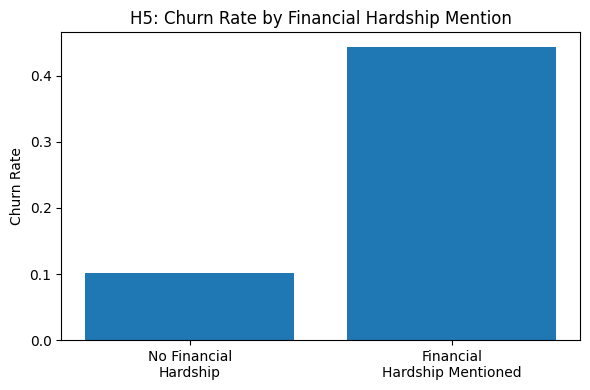

In [59]:
table = pd.crosstab(df['crm_financial_hardship_mentioned'], df['churn'])
chi2, p, _, _ = chi2_contingency(table)
print(p)
if p < 0.05:
    print("Reject H0 hypothesis: There is a significant association between financial hardship mentioned and churn.")  
else:    
    print("Fail to reject H0 hypothesis: There is no significant association between financial hardship mentioned and churn.")



table = pd.crosstab(df['crm_financial_hardship_mentioned'], df['churn'])

rates = table[1] / table.sum(axis=1)

fig, ax = plt.subplots(figsize=(6, 4))

ax.bar(
    ['No Financial\nHardship', 'Financial\nHardship Mentioned'],
    rates.values
)

ax.set_title('H5: Churn Rate by Financial Hardship Mention')
ax.set_ylabel('Churn Rate')

plt.tight_layout()
plt.show()

####        Hypothesis 1: tenure_years
H0: Tenure does not affect churn  
H1: Tenure affects churn  
Test Type: T-test

p-value: 9.365305123315453e-165
Reject H0 hypothesis: There is a significant difference in tenure years between churned and non-churned customers.


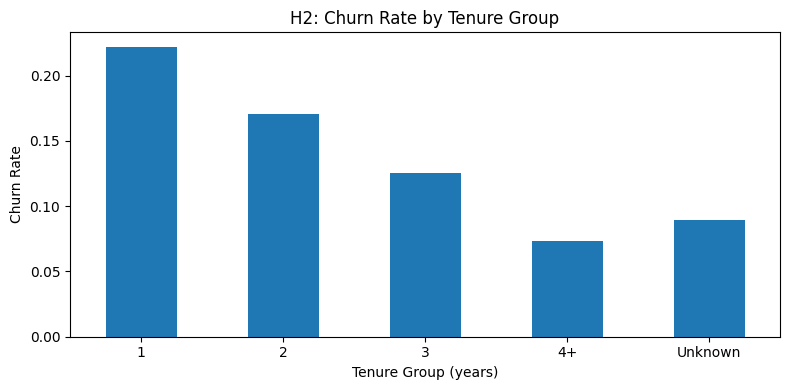

In [56]:
from scipy.stats import ttest_ind

t, p = ttest_ind(
    df[df['churn']==1]['tenure_years'],
    df[df['churn']==0]['tenure_years'],
    nan_policy='omit'
)

print("p-value:", p)
if p < 0.05:
    print("Reject H0 hypothesis: There is a significant difference in tenure years between churned and non-churned customers.")
else:    
    print("Fail to reject H0 hypothesis: There is no significant difference in tenure years between churned and non-churned customers.")
    
tg = df.groupby('tenure_group')['churn'].mean().sort_index()
fig, ax = plt.subplots(figsize=(8, 4))
tg.plot(kind='bar', ax=ax)
ax.set_title('H2: Churn Rate by Tenure Group')
ax.set_xlabel('Tenure Group (years)')
ax.set_ylabel('Churn Rate')
ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

####        Hypothesis 4: tenure_group
H0: Tenure group does not affect churn  
H1: Tenure group affects churn  
Test Type: Chi-square 

In [51]:
table = pd.crosstab(df['tenure_group'], df['churn'])

chi2, p, _, _ = chi2_contingency(table)

print("p-value:", p)
if p < 0.05:
    print("Reject H0 hypothesis: There is a significant association between tenure group and churn.")   
else:    
    print("Fail to reject H0 hypothesis: There is no significant association between tenure group and churn.")

p-value: 3.3741061324149976e-208
Reject H0 hypothesis: There is a significant association between tenure group and churn.


Chi2_value: 38.67244726259526
P-value: 5.012348201057114e-10
Result: SIGNIFICANT (p < 0.05)
Reject H0: There is a significant association between serious complaint and churn.


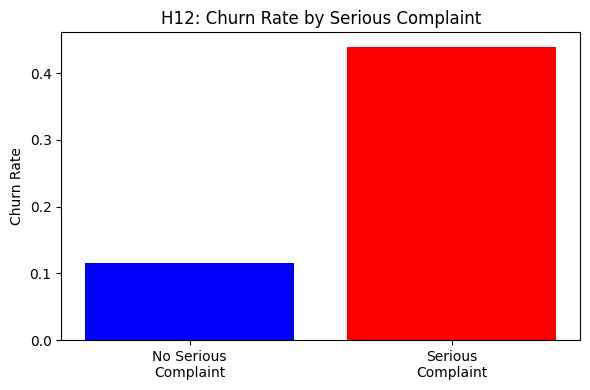

In [65]:
contingency = pd.crosstab(df['serious_complaint_flag'], df['churn'])
chi2, p_value, _, _ = chi2_contingency(contingency)
rates = df.groupby('serious_complaint_flag')['churn'].mean()

print("Chi2_value:", chi2)
print("P-value:", p_value)
if p_value < 0.05:
    print('Result: SIGNIFICANT (p < 0.05)')
    print("Reject H0: There is a significant association between serious complaint and churn.")
else:
    print('Result: NOT SIGNIFICANT (p >= 0.05)')
    print("Fail to reject H0: There is no significant association between serious complaint and churn.")    

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['No Serious\nComplaint', 'Serious\nComplaint'],rates.values, color=['blue', 'red'])
ax.set_title('H12: Churn Rate by Serious Complaint')
ax.set_ylabel('Churn Rate')
plt.tight_layout()
plt.show()

####        Hypothesis
H0: Sentiment category is independent of churn  
H1: Sentiment category has a significant association with churn  
Test Type: Chi-square

p-value: 1.8086016190539038e-212
Reject H0 hypothesis: There is a significant association between sentiment category and churn.


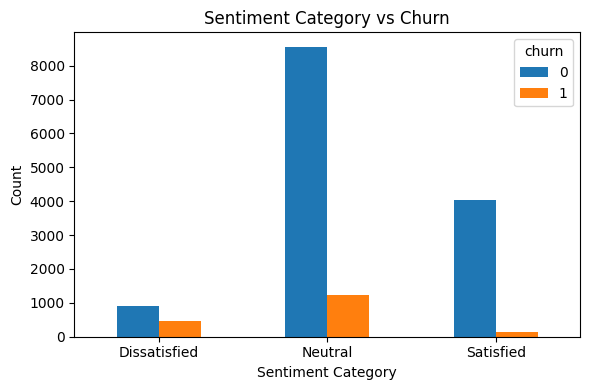

In [69]:
df_sent = df.dropna(subset=['sentiment_category'])
table = pd.crosstab(df_sent['sentiment_category'], df_sent['churn'])
chi2, p, _, _ = chi2_contingency(table)

print("p-value:", p)
if p < 0.05:
    print("Reject H0 hypothesis: There is a significant association between sentiment category and churn.")
else:    
    print("Fail to reject H0 hypothesis: There is no significant association between sentiment category and churn.")

fig, ax = plt.subplots(figsize=(6, 4))
table.plot(kind='bar', ax=ax)

ax.set_title('Sentiment Category vs Churn')
ax.set_xlabel('Sentiment Category')
ax.set_ylabel('Count')

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()